In [1]:
import pandas as pd 
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2B0, ResNet101V2, MobileNetV2
import os
import seaborn as sns
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow.keras import models ,layers
from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Average, Input,Lambda
from sklearn.utils.class_weight import compute_class_weight

In [2]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    print("Memory growth enabled.")
  except RuntimeError as e:
    print(e)

Memory growth enabled.


In [3]:
tf.version

<module 'tensorflow._api.v2.version' from 'C:\\Users\\Someshwar Kumbar\\anaconda3\\envs\\pyformodel\\lib\\site-packages\\tensorflow\\_api\\v2\\version\\__init__.py'>

In [4]:
data_dir="raw_data/Merged Dataset"

In [5]:
image_path=[os.path.join(root,file)
               for  root ,dirs,files in os.walk(data_dir)
                for file in files
                    if file.lower().endswith(('.jpg','.png'))
           ]
labels=[os.path.basename(os.path.dirname(p)) for p in image_path]

df=pd.DataFrame({
    'file_path':[str(p) for p in image_path],
    'label':labels
})

In [6]:
print(f"the total images:{len(df)}")
print(f"the total class :{df['label'].nunique()}")

the total images:79084
the total class :88


C:\Users\Someshwar Kumbar\AppData\Local\Temp\ipykernel_27448\2244290471.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


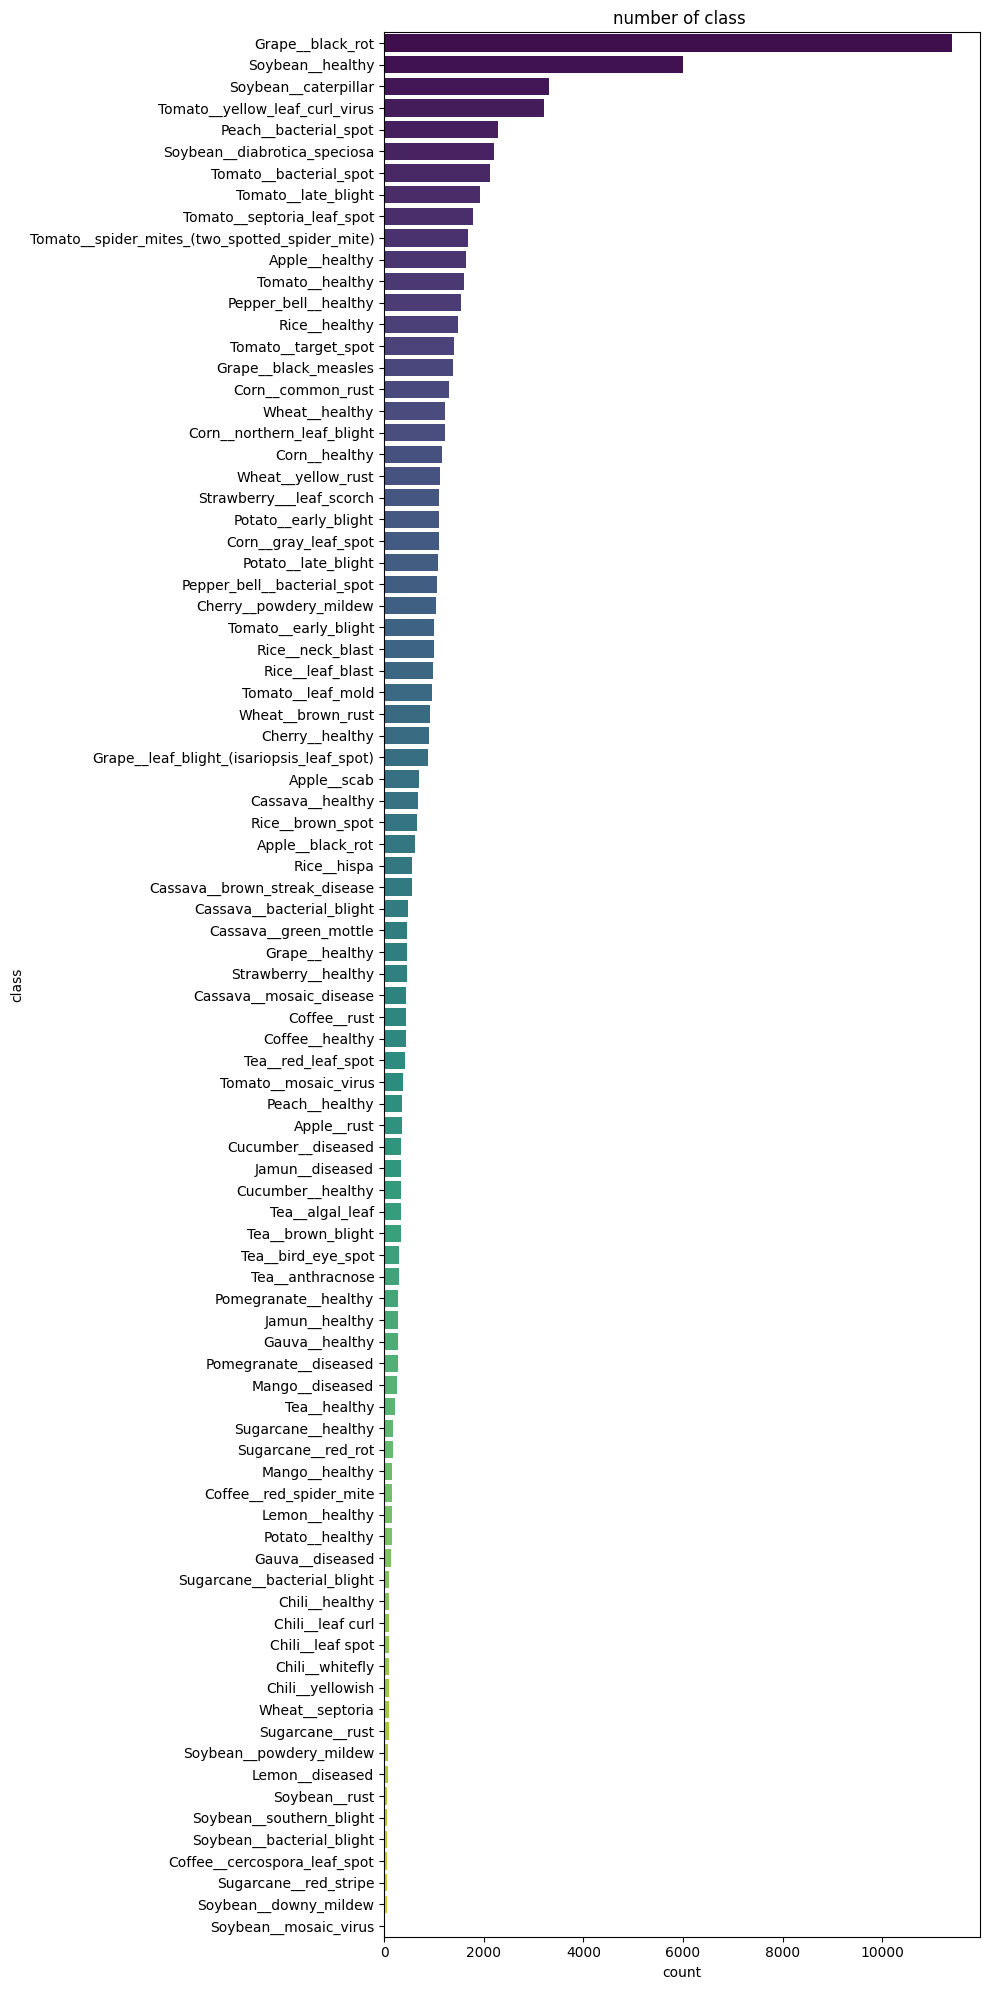

In [7]:
### let's plot calss distrubution table
plt.figure(figsize=(10,20))
sns.countplot(
    data=df,
    y='label',
    order=df['label'].value_counts().index,
    palette='viridis'
)
plt.title("number of class ")
plt.xlabel("count")
plt.ylabel("class")
plt.tight_layout()


In [8]:
##let's fix the photo size and configering
config={
    'image_size':224,
    'batch_size':16,
    'epochs':20,
    'seed':42,
    'model_names':['EfficientNetV2B0', 'ResNet101V2', 'MobileNetV2'],
    'learing_rate':1e-4,
    'dropout_rate':0.3,
     'l2_regularization_rate': 0.001
}

In [9]:
# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_seed(config['seed'])

# Mixed Precision
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

print(mixed_precision)

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 A Laptop GPU, compute capability 8.9
<module 'keras.api._v2.keras.mixed_precision' from 'C:\\Users\\Someshwar Kumbar\\anaconda3\\envs\\pyformodel\\lib\\site-packages\\keras\\api\\_v2\\keras\\mixed_precision\\__init__.py'>


In [10]:
used_classes = [
 'Apple__black_rot',
 'Apple__healthy',
 'Apple__rust',
 'Apple__scab',
 'Cassava__bacterial_blight',
 'Cassava__brown_streak_disease',
 'Cassava__green_mottle',
 'Cassava__healthy',
 'Cassava__mosaic_disease',
 'Cherry__healthy',
 'Cherry__powdery_mildew',
 'Chili__healthy',
 'Chili__leaf curl',
 'Chili__leaf spot',
 'Chili__whitefly',
 'Chili__yellowish',
 'Coffee__cercospora_leaf_spot',
 'Coffee__healthy',
 'Coffee__red_spider_mite',
 'Coffee__rust',
 'Corn__common_rust',
 'Corn__gray_leaf_spot',
 'Corn__healthy',
 'Corn__northern_leaf_blight',
 'Cucumber__diseased',
 'Cucumber__healthy',
 'Gauva__diseased',
 'Gauva__healthy',
 'Grape__black_measles',
 'Grape__black_rot',
 'Grape__healthy',
 'Grape__leaf_blight_(isariopsis_leaf_spot)',
 'Jamun__diseased',
 'Jamun__healthy',
 'Lemon__diseased',
 'Lemon__healthy',
 'Mango__diseased',
 'Mango__healthy',
 'Peach__bacterial_spot',
 'Peach__healthy',
 'Pepper_bell__bacterial_spot',
 'Pepper_bell__healthy',
 'Pomegranate__diseased',
 'Pomegranate__healthy',
 'Potato__early_blight',
 'Potato__healthy',
 'Potato__late_blight',
 'Rice__brown_spot',
 'Rice__healthy',
 'Rice__hispa',
 'Rice__leaf_blast',
 'Rice__neck_blast',
 'Soybean__bacterial_blight',
 'Soybean__caterpillar',
 'Soybean__diabrotica_speciosa',
 'Soybean__downy_mildew',
 'Soybean__healthy',
 'Soybean__mosaic_virus',
 'Soybean__powdery_mildew',
 'Soybean__rust',
 'Soybean__southern_blight',
 'Strawberry___leaf_scorch',
 'Strawberry__healthy',
 'Sugarcane__bacterial_blight',
 'Sugarcane__healthy',
 'Sugarcane__red_rot',
 'Sugarcane__red_stripe',
 'Sugarcane__rust',
 'Tea__algal_leaf',
 'Tea__anthracnose',
 'Tea__bird_eye_spot',
 'Tea__brown_blight',
 'Tea__healthy',
 'Tea__red_leaf_spot',
 'Tomato__bacterial_spot',
 'Tomato__early_blight',
 'Tomato__healthy',
 'Tomato__late_blight',
 'Tomato__leaf_mold',
 'Tomato__mosaic_virus',
 'Tomato__septoria_leaf_spot',
 'Tomato__spider_mites_(two_spotted_spider_mite)',
 'Tomato__target_spot',
 'Tomato__yellow_leaf_curl_virus',
 'Wheat__brown_rust',
 'Wheat__healthy',
 'Wheat__septoria',
 'Wheat__yellow_rust']
n_classes = len(used_classes)

In [11]:
n_classes

88

In [12]:
df =df[df['label'].isin(used_classes).reset_index(drop=True)]
len(df)

79084

In [13]:
df.describe()

,file_path,label
count,79084,79084
unique,79084,88
top,raw_data/Merged Dataset\Apple__black_rot\0090d...,Grape__black_rot
freq,1,11390


In [14]:
##let's do train test split 
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=config['seed'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=config['seed'])

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 55358 | Val: 11863 | Test: 11863


In [15]:
# lets do traing dataset with labels and do augmentation
train_data=ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True
)

val_data=ImageDataGenerator(rescale=1./255)
test_data=ImageDataGenerator(rescale=1./255)


##let's genertors

train_gen=train_data.flow_from_dataframe(
    train_df,
    x_col='file_path',
    y_col='label',
    target_size=(config['image_size'], config['image_size']),
    batch_size=config['batch_size'],
    class_mode='categorical',
    shuffle=True,
    seed=config['seed']
)

val_gen=train_data.flow_from_dataframe(
    val_df,
    x_col='file_path',
    y_col='label',
    target_size=(config['image_size'], config['image_size']),
    batch_size=config['batch_size'],
    class_mode='categorical',
    shuffle=True,
)

test_gen=train_data.flow_from_dataframe(
    test_df,
    x_col='file_path',
    y_col='label',
    target_size=(config['image_size'], config['image_size']),
    batch_size=config['batch_size'],
    class_mode='categorical',
    shuffle=True,
)

Found 55358 validated image filenames belonging to 88 classes.
Found 11863 validated image filenames belonging to 88 classes.
Found 11863 validated image filenames belonging to 88 classes.


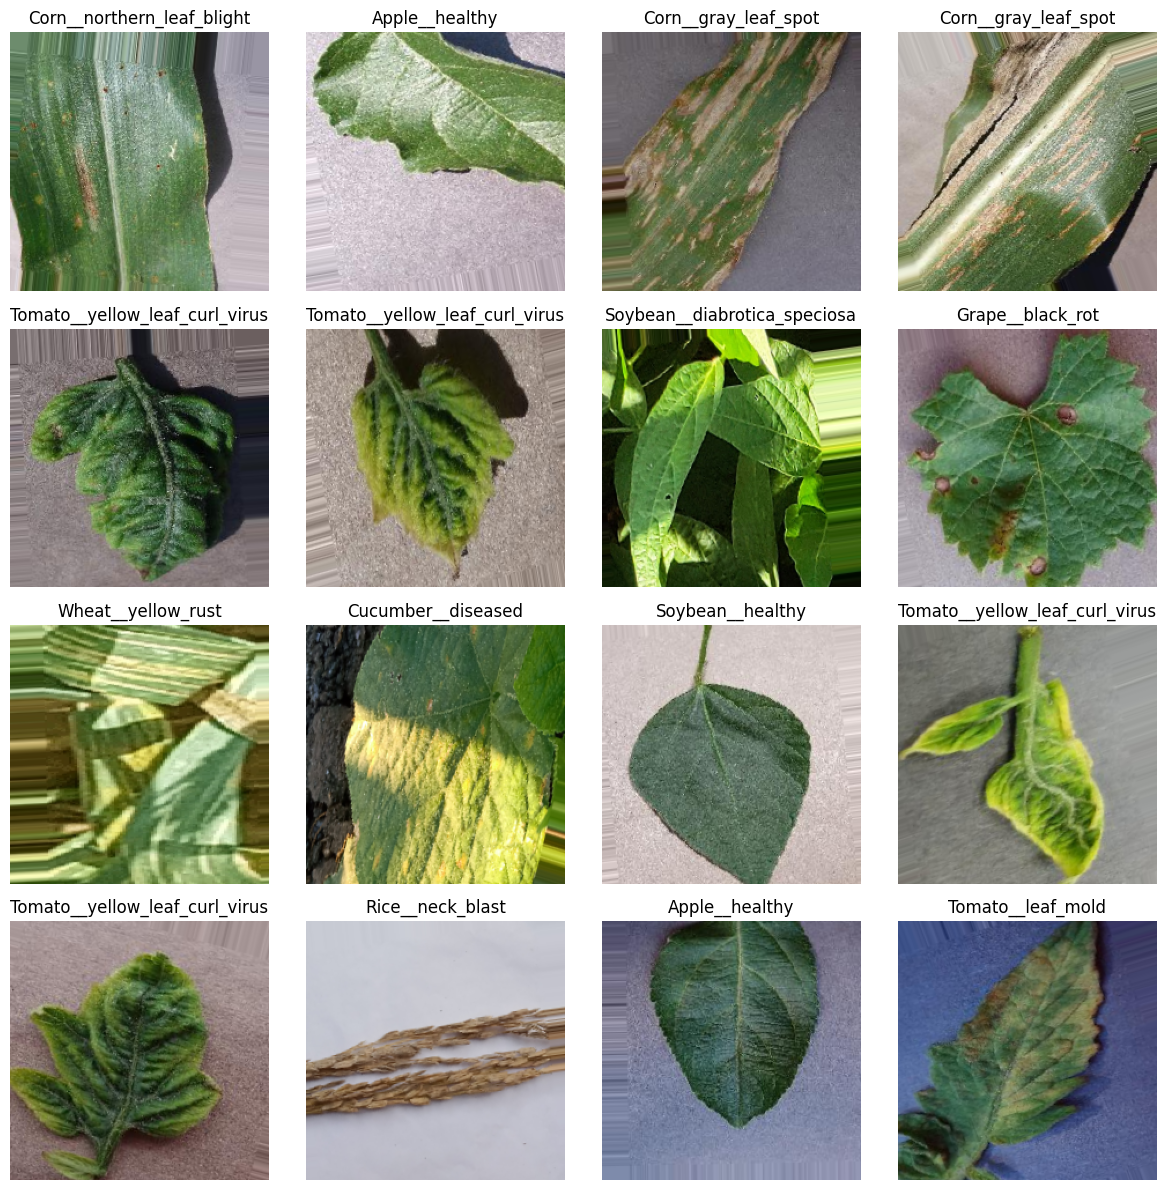

In [16]:
###let's plot some samples
image , labels= next(train_gen)
class_name= list(train_gen.class_indices.keys())

plt.figure(figsize=(12, 12))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(image[i])
    label_index = tf.argmax(labels[i]).numpy()
    plt.title(class_name[label_index], fontsize=12)
    plt.axis("off")
plt.tight_layout()

In [17]:
#### now dataset is ready lets train an model with all the base model 
def build_model(base_model_name='EfficientNet', input_shape=(224, 224, 3), n_classes=18):
    if base_model_name == 'EfficientNet':
        base_model = EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base_model_name == 'ResNet':
        base_model = ResNet101V2(weights='imagenet', include_top=False, input_shape=input_shape)
    elif base_model_name == 'MobileNet':
        base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError("Unsupported base model.")

    base_model.trainable=True

        ### buliding model
        
    model=models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(config['dropout_rate']),
        layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(config['l2_regularization_rate'])),
        layers.Dropout(config['dropout_rate']),
        layers.Dense(n_classes, activation='softmax')
            
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(config['learing_rate']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [18]:
model_eff_net=build_model('EfficientNet',input_shape=(config['image_size'], config['image_size'], 3),n_classes=n_classes)

In [19]:
modle_res_net=build_model('ResNet',input_shape=(config['image_size'], config['image_size'], 3),n_classes=n_classes)

modle_mobile_net=build_model('MobileNet',input_shape=(config['image_size'], config['image_size'], 3),n_classes=n_classes)

In [20]:
model_eff_net.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-b0 (Function  (None, 7, 7, 1280)       5919312   
 al)                                                             
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 88)                2

In [21]:
modle_mobile_net.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_2   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_4 (Dropout)         (None, 1280)              0         
                                                                 
 dense_4 (Dense)             (None, 256)               327936    
                                                                 
 dropout_5 (Dropout)         (None, 256)               0         
                                                                 
 dense_5 (Dense)             (None, 88)               

In [22]:
modle_res_net.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet101v2 (Functional)    (None, 7, 7, 2048)        42626560  
                                                                 
 global_average_pooling2d_1   (None, 2048)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_2 (Dropout)         (None, 2048)              0         
                                                                 
 dense_2 (Dense)             (None, 256)               524544    
                                                                 
 dropout_3 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 88)                22616     
                                                      

In [23]:
### let'set all early stropping
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        ModelCheckpoint(f"{model_name}_best.keras", monitor='val_loss', save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, min_lr=1.25e-5, patience=2, verbose=1)
    ]


In [24]:
###let's fix calss imbalance
# Get class indices
class_indices = {label: idx for idx, label in enumerate(train_df['label'].unique())}
train_df['label_idx'] = train_df['label'].map(class_indices)

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_idx']),
    y=train_df['label_idx']
)

# Convert to dict
class_weights = {i: w for i, w in enumerate(class_weights)}


In [25]:
class_weights

{0: 2.9955627705627705,
 1: 0.07889980958462083,
 2: 0.8201671210145787,
 3: 0.6498638241923366,
 4: 0.9813856190611261,
 5: 0.2795858585858586,
 6: 0.6399472856746509,
 7: 1.9720005699629524,
 8: 9.251002673796792,
 9: 0.6867556570067487,
 10: 0.14981380848253914,
 11: 1.0113636363636365,
 12: 0.42078139252052293,
 13: 2.5994552967693463,
 14: 0.8986688311688311,
 15: 0.73317969908879,
 16: 0.5362900100751763,
 17: 0.5621699569420749,
 18: 0.5451197416102096,
 19: 2.476646385110952,
 20: 0.27161838593185744,
 21: 1.3271480629075565,
 22: 8.986688311688312,
 23: 0.6037122666201361,
 24: 0.5840930193297881,
 25: 0.822311348781937,
 26: 1.608870030225529,
 27: 0.46840519867325525,
 28: 0.39121155585707823,
 29: 0.9156742093423316,
 30: 1.283812615955473,
 31: 2.6320844427538987,
 32: 0.5044652620835459,
 33: 0.40742757889778614,
 34: 0.8910314190059233,
 35: 0.8212378352717778,
 36: 0.7357522594364699,
 37: 3.242619493908154,
 38: 1.3765168092301572,
 39: 1.906267217630854,
 40: 13.67539

In [26]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [27]:
history_mobile=modle_mobile_net.fit(
    train_gen,
    validation_data=val_gen,
    epochs=config['epochs'],
    callbacks=get_callbacks('mobile_net'),
    class_weight=class_weights,
    verbose=1
)
tf.keras.models.save_model(model_eff_net, 'model_mobel 1.h5')

Epoch 1/20
3460/3460 [==============================] - ETA: 0s - loss: 4.4544 - accuracy: 0.5839
Epoch 1: val_loss improved from inf to 1.45410, saving model to mobile_net_best.keras
3460/3460 [==============================] - 1935s 553ms/step - loss: 4.4544 - accuracy: 0.5839 - val_loss: 1.4541 - val_accuracy: 0.7351 - lr: 1.0000e-04
Epoch 2/20
3460/3460 [==============================] - ETA: 0s - loss: 2.1377 - accuracy: 0.7558
Epoch 2: val_loss improved from 1.45410 to 1.10505, saving model to mobile_net_best.keras
3460/3460 [==============================] - 1897s 548ms/step - loss: 2.1377 - accuracy: 0.7558 - val_loss: 1.1051 - val_accuracy: 0.8113 - lr: 1.0000e-04
Epoch 3/20
3460/3460 [==============================] - ETA: 0s - loss: 1.7341 - accuracy: 0.8106
Epoch 3: val_loss improved from 1.10505 to 0.95862, saving model to mobile_net_best.keras
3460/3460 [==============================] - 1883s 544ms/step - loss: 1.7341 - accuracy: 0.8106 - val_loss: 0.9586 - val_accuracy:

In [28]:
!pip install pickle

ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle


In [32]:
import pickle
with open('model_mobel 1_history.pkl', 'wb') as file_pi:
    pickle.dump(history_mobile.history, file_pi)

print("Model and history saved successfully.")

Model and history saved successfully.


In [30]:
def plot_history(history, model_name="Model"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Val Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.title(f'{model_name} Loss')
    plt.legend()
    plt.show()

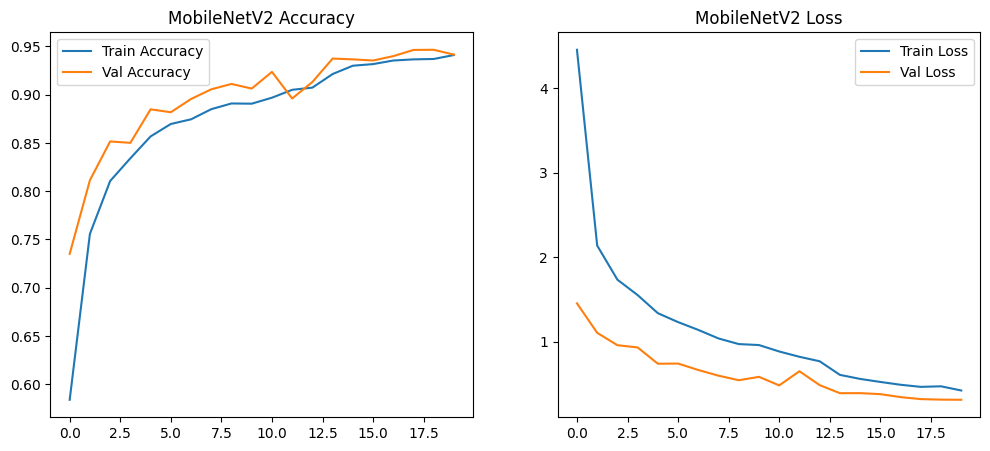

In [31]:
plot_history(history_mobile, "MobileNetV2")

In [ ]:
### let's train model with efficientNet

history_eff=model_eff_net.fit(
    train_gen,
    validation_data=val_gen,
    epochs=config['epochs'],
    callbacks=get_callbacks('efficient_net'),
    class_weight=class_weights,
    verbose=1
)

In [ ]:
history_res=modle_res_net.fit(
    train_gen,
    validation_data=val_gen,
    epochs=config['epochs'],
    callbacks=get_callbacks('res_net'),
    class_weight=class_weights,
    verbose=1
)